In [1]:
import numpy as np
from matplotlib import pyplot as plt
import nibabel as nb
from scipy.ndimage import gaussian_filter
from scipy.ndimage import distance_transform_edt
from glob import glob
import tifffile as tiff
import sys
import os
from glob import glob
sys.path.append('../')
from scipy import ndimage as ndi
from skimage.measure import block_reduce

# from slice_structure_identification_functions import compute_signed_distance_weight as compute_signed_distance_weight
# from slice_structure_identification_functions import compute_signed_distance_weight_filled as compute_signed_distance_weight_filled

import importlib


import slice_registration_functions
importlib.reload(slice_registration_functions)
from slice_registration_functions import apply_coordinate_mapping_2d, downsample_image, build_centroid_image

In [2]:
# This SHOULD be as similar as possible to the registration pipeline downsampling behavior in run_slice_registration_optimized_newReg_sdf_v2.py
# Behavior to match:
# 1) symmetric proportional padding (prop_pad on each side),
# 2) extra bottom/right padding so shape is divisible by the downsample factor,
# 3) block-sum downsampling.


# ##this is effectively identical to downsample_image in slice_registration_functions.py, so we can get rid of it
# def downsample_with_registration_padding(image, rescale, prop_pad=0.2, pad_value=0):
#     arr = np.asarray(image)
#     if arr.ndim != 2:
#         raise ValueError(f"Expected a 2D array, got shape {arr.shape}")

#     #breaks if not int. as it stands, were doing this when we define rescale, but this shouldnt change the value if we redo it here to be safe
#     factor = max(1, int(round(rescale)))

#     # Symmetric proportional padding
#     pad0 = int(np.ceil(arr.shape[0] * prop_pad))
#     pad1 = int(np.ceil(arr.shape[1] * prop_pad))
#     arr = np.pad(arr, ((pad0, pad0), (pad1, pad1)), mode="constant", constant_values=pad_value)

#     # Extra padding only on bottom/right to make dimensions divisible by factor. TODO: Is this needed?
#     extra0 = (-arr.shape[0]) % factor
#     extra1 = (-arr.shape[1]) % factor
#     if extra0 or extra1:
#         arr = np.pad(arr, ((0, extra0), (0, extra1)), mode="constant", constant_values=pad_value)

#     return block_reduce(arr, block_size=(factor, factor), func=np.sum)


#crop or pad, depending if image is too large (crop) or too small (pad). The reg pipeline does this when it picks one image in the stack to use as a template. We need to do something similar, but since we have the actual source image shape and the target shape (after downsampling+padding), we can just do it to that image size directly. I think this works but TODO: test on other images.
def center_crop_or_pad_2d(image, target_shape, pad_value=0):
    arr = np.asarray(image)
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D array, got shape {arr.shape}")

    target_h, target_w = int(target_shape[0]), int(target_shape[1])

    # Center-crop if too large.
    start_h = max((arr.shape[0] - target_h) // 2, 0)
    start_w = max((arr.shape[1] - target_w) // 2, 0)
    end_h = start_h + min(target_h, arr.shape[0])
    end_w = start_w + min(target_w, arr.shape[1])
    arr = arr[start_h:end_h, start_w:end_w]

    # Center-pad if too small.
    pad_h_total = max(target_h - arr.shape[0], 0)
    pad_w_total = max(target_w - arr.shape[1], 0)
    pad_h0 = pad_h_total // 2
    pad_h1 = pad_h_total - pad_h0
    pad_w0 = pad_w_total // 2
    pad_w1 = pad_w_total - pad_w0

    if pad_h_total or pad_w_total:
        arr = np.pad(arr, ((pad_h0, pad_h1), (pad_w0, pad_w1)), mode="constant", constant_values=pad_value)

    return arr


zefir_0000__Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0001__Image_01_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0002__Image_02_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0003__Image_02_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0004__Image_03_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0005__Image_03_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0006__Image_04_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0007__Image_04_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0008__Image_05_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0009__Image_05_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0010__Image_06_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0011__Image_06_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0012__Image_07_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0013__Image_07_-_20x_02_cellCoun

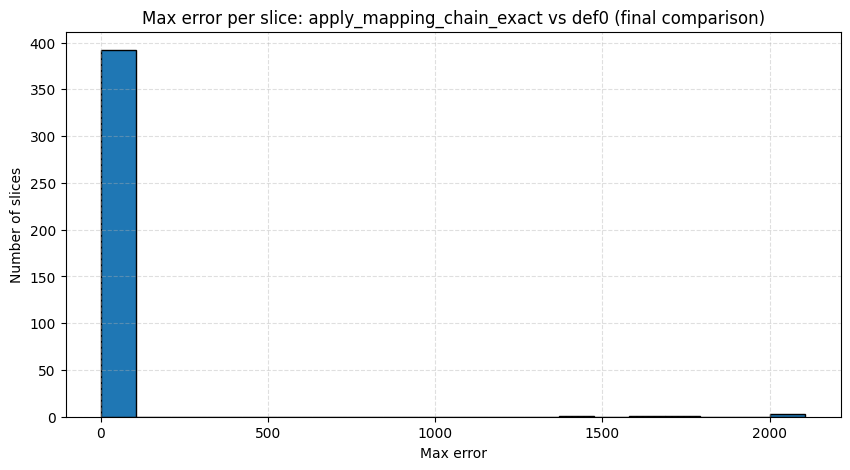

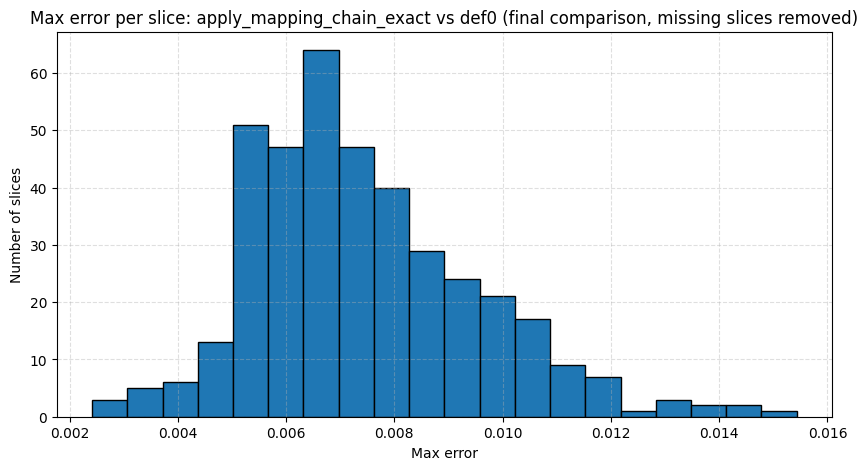

In [3]:
root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies'
# root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_50/'

# Generate list of slice directories by globbing based on unique numeric prefix (zefir_XXXX_...)
# `glob` may be a function from previous imports, so call it directly.
orig_fnames = sorted(glob(os.path.join(root_dir, 'zefir_????_*_pix.nii.gz')))

max_errors = []
missing_slices = []
bad_slices = [] #exceed max_error_thresh
max_error_thresh = 5.0
for name_idx, orig_fname in enumerate(orig_fnames):
    slice_name = os.path.basename(orig_fname)
    base_slice = slice_name.split('_downsample_10p002um_pix')[0]

    source_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix.nii.gz")
    # mapping_img = os.path.join(root_dir, f"init_translation_slice_{base_slice.split('_')[1]}/{base_slice}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
    mapping_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
    mapping_img3 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
    mapping_img4 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")
    mapping_img5 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter4_ants-map.nii.gz")
    mapping_img6 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter5_ants-map.nii.gz")
    mapping_img7 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter6_ants-map.nii.gz")
    mapping_img8 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter7_ants-map.nii.gz")
    mapping_img9 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter8_ants-map.nii.gz")
    mapping_img10 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-map.nii.gz")
    
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-def0.nii.gz")

    if not (os.path.exists(source_img) and os.path.exists(mapping_img) and os.path.exists(mapping_img3) and os.path.exists(mapping_img4)):
        missing_slices.append(slice_name)
        continue
    print(slice_name)
    src = nb.load(source_img)
    m1_ = nb.load(mapping_img)
    m2_ = nb.load(mapping_img3)
    m3_ = nb.load(mapping_img4)
    m4_ = nb.load(mapping_img5)
    m5_ = nb.load(mapping_img6)
    m6_ = nb.load(mapping_img7)
    m7_ = nb.load(mapping_img8)
    m8_ = nb.load(mapping_img9)
    m9_ = nb.load(mapping_img10)
    
    comparison = nb.load(final_comparison_img).get_fdata()
    # seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_).get_fdata()
    seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_).get_fdata()
    # comp_exact = apply_mapping_chain_exact(src, [m1_, m2_, m3_, m4_, m5_, m6_, m7_, m8_, m9_]).get_fdata()

    max_err = np.abs(seq -comparison).max()
    max_errors.append(max_err)
    if max_err > max_error_thresh:
        bad_slices.append((slice_name, max_err, name_idx))

max_errors = np.array(max_errors)
print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

plt.figure(figsize=(10, 5))
plt.hist(max_errors, bins=20, color='tab:blue', edgecolor='black')
plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison)')
plt.xlabel('Max error')
plt.ylabel('Number of slices')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(max_errors[max_errors<max_error_thresh], bins=20, color='tab:blue', edgecolor='black')
plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison, missing slices removed)')

plt.xlabel('Max error')
plt.ylabel('Number of slices')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()




In [5]:
orig_fnames

['/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies/zefir_0000__Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz',
 '/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies/zefir_0001__Image_01_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz',
 '/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies/zefir_0002__Image_02_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz',
 '/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies/zefir_0003__Image_02_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz',
 '/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies/zefir_0004__Image_03_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz',
 '/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies/zefir_0005__Image_03_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz',
 '/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies/zefir_0006__Image_04_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz',
 '/tmp/zefir_sliceReg_optimized_v2_rescal

In [4]:
# JUST DOWNSAMPLE TESTING

slice_pathroot_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'
label_dir = '/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/'

# input_res = 0.345
# target_res = 400.0
# rescale = target_res / input_res

rescale = 63158 / 77
rescale = int(round(rescale))

orig_cell_counts_fname = '/data/neuralabc/neuralabc_volunteers/macaque/testProject2/results_cell_counts/_Image_03_-_20x_cellCount_29_downsample_10p002um_pix.tif'
orig_cell_counts = tiff.imread(orig_cell_counts_fname)

labeled_mask = tiff.imread('/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0116__Image_03_-_20x_mask.ome.tif').astype(bool).astype(np.uint8)
src = nb.load('/tmp/zefir_sliceReg_optimized_v2_rescale_40/zefir_0116__Image_04_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz')

# Registration-matched strategy (same padding/downsampling logic as run_slice_registration_optimized_newReg_sdf_v2.py).
_ds_reg = downsample_with_registration_padding(labeled_mask, rescale)
_ds_reg_to_src = center_crop_or_pad_2d(_ds_reg, target_shape=src.shape)

# Existing notebook/script helpers for comparison.
_ds_mtc = downsample_mask_to_counts(labeled_mask, rescale, mode='qupath')
_ds_img = downsample_image(labeled_mask, rescale, pad_value=0)

_ds_img_to_src = center_crop_or_pad_2d(_ds_img, target_shape=src.shape)

diff = _ds_reg_to_src - _ds_img_to_src

print(f"Max absolute difference between registration-matched downsample and existing downsample: {np.abs(diff).max()}")

Exception in worker
Traceback (most recent call last):
  File "/home/remoteuser/johmat/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/lib/python3.11/concurrent/futures/thread.py", line 81, in _worker
    work_item = work_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "src/gevent/queue.py", line 406, in gevent._gevent_cqueue.SimpleQueue.get
  File "src/gevent/queue.py", line 422, in gevent._gevent_cqueue.SimpleQueue.get
  File "src/gevent/queue.py", line 398, in gevent._gevent_cqueue.SimpleQueue._SimpleQueue__get_or_peek
  File "src/gevent/_waiter.py", line 154, in gevent._gevent_c_waiter.Waiter.get
  File "src/gevent/_greenlet_primitives.py", line 65, in gevent._gevent_c_greenlet_primitives.SwitchOutGreenletWithLoop.switch
  File "src/gevent/_gevent_c_greenlet_primitives.pxd", line 35, in gevent._gevent_c_greenlet_primitives._greenlet_switch
gevent.exceptions.LoopExit: This operation would block forever
	Hub: <Hub '' at 0x7efc606adcb0 epoll pending=0 r

NameError: name 'downsample_with_registration_padding' is not defined

In [5]:
print(f"{'downsample factor':<40}: {rescale}")
print(f"{'registration-like shape':<40}: {_ds_reg.shape}")
print(f"{'registration-like aspect ratio':<40}: {_ds_reg.shape[0]/_ds_reg.shape[1]}")
print(f"{'registration-like -> src shape':<40}: {_ds_reg_to_src.shape}")
print(f"{'registration-like -> src aspect ratio':<40}: {_ds_reg_to_src.shape[0]/_ds_reg_to_src.shape[1]}")
print(f"{'downsample_image shape':<40}: {_ds_img.shape}")
print(f"{'downsample_image aspect ratio':<40}: {_ds_img.shape[0]/_ds_img.shape[1]}")
print(f"{'downsample_mask_to_counts shape':<40}: {_ds_mtc.shape}")
print(f"{'downsample_mask_to_counts aspect ratio':<40}: {_ds_mtc.shape[0]/_ds_mtc.shape[1]}")
print(f"{'src shape':<40}: {src.shape}")
print(f"{'src aspect ratio':<40}: {src.shape[0]/src.shape[1]}")
print(f"{'labeled_mask shape':<40}: {labeled_mask.shape}")
print(f"{'labeled_mask aspect ratio':<40}: {labeled_mask.shape[0]/labeled_mask.shape[1]}")
print(f"{'orig_cell_counts shape':<40}: {orig_cell_counts.shape}")
print(f"{'orig_cell_counts aspect ratio':<40}: {orig_cell_counts.shape[0]/orig_cell_counts.shape[1]}")

downsample factor                       : 820


NameError: name '_ds_reg' is not defined

In [ ]:
##LOG from test run with requested pixel size = 10, like the qupath export script

# downsample factor                       : 29
# downsample_image shape                  : (3050, 3671)
# downsample_image aspect ratio           : 0.8308362843911741
# downsample_mask_to_counts shape         : (2178, 2622)
# downsample_mask_to_counts aspect ratio  : 0.8306636155606407
# src shape                               : (77, 103)
# src aspect ratio                        : 0.7475728155339806
# labeled_mask shape                      : (63158, 76025)
# labeled_mask aspect ratio               : 0.8307530417625781
# orig_cell_counts shape                  : (2178, 2622)
# orig_cell_counts aspect ratio           : 0.8306636155606407

In [ ]:
##LOG from test run with requested pixel size = 400, which should be the size of the pixels in the registration pipeline (10um downsampled by 40)

# downsample factor                       : 1159
# downsample_image shape                  : (77, 92)
# downsample_image aspect ratio           : 0.8369565217391305
# downsample_mask_to_counts shape         : (55, 66)
# downsample_mask_to_counts aspect ratio  : 0.8333333333333334
# src shape                               : (77, 103)
# src aspect ratio                        : 0.7475728155339806
# labeled_mask shape                      : (63158, 76025)
# labeled_mask aspect ratio               : 0.8307530417625781
# orig_cell_counts shape                  : (2178, 2622)
# orig_cell_counts aspect ratio           : 0.8306636155606407

In [ ]:
##LOG from test run where rescale was calculated as 63158 / 77 rounded, which is the input image x size by the src image x size

# downsample factor                       : 820
# downsample_image shape                  : (108, 130)
# downsample_image aspect ratio           : 0.8307692307692308
# downsample_mask_to_counts shape         : (78, 93)
# downsample_mask_to_counts aspect ratio  : 0.8387096774193549
# src shape                               : (77, 103)
# src aspect ratio                        : 0.7475728155339806
# labeled_mask shape                      : (63158, 76025)
# labeled_mask aspect ratio               : 0.8307530417625781
# orig_cell_counts shape                  : (2178, 2622)
# orig_cell_counts aspect ratio           : 0.8306636155606407

In [20]:
slice_pathroot_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies'

root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies'

label_dir = '/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/'


input_res = 0.345
target_res = 400.0
rescale = target_res / input_res
rescale = int(round(rescale))



# orig_fnames = sorted(glob(os.path.join(root_dir, 'zefir_????_*_pix.nii.gz')))
# #hardcode specific slice with large visual shift for testing
orig_fnames = sorted(glob(os.path.join(root_dir, 'zefir_0240_*_pix.nii.gz')))

max_errors = []
missing_slices = []
bad_slices = [] #exceed max_error_thresh
max_error_thresh = 5.0
final_space_labels = {}
final_space_labels['img'] =[]
final_space_labels['fname_header'] =[]
final_space_labels['final_reg_space_def0'] = []
for name_idx, orig_fname in enumerate(orig_fnames):
    
    # labeled_maskos.path.basename(PC_files[0].split('_mask_')[0])
    # labeled_mask 
    
    slice_name = os.path.basename(orig_fname)
    base_slice = slice_name.split('_downsample_10p002um_pix')[0]
    fname_header = base_slice.split('__')[0]
    labeled_mask = glob(os.path.join(label_dir, f"{fname_header}_*_mask*.tif"))
    ##############################################################################
    #hardcode to correct for off-by-one error in the naming
    # labeled_mask = glob(os.path.join(label_dir, f"zefir_0250_*_mask*.ome.tif"))
    ##############################################################################
    if len(labeled_mask) == 0:
        # print(f"No labeled mask found for {slice_name}")
        continue
    elif len(labeled_mask) > 1:
        # print(f"Multiple labeled masks found for {slice_name}: {labeled_mask}")
        continue        
    
        
    labeled_mask_fname = labeled_mask[0]
    if os.path.exists(labeled_mask_fname):
        print(f"Found labeled mask for {slice_name}: {labeled_mask_fname}")
    
    labeled_mask = tiff.imread(labeled_mask_fname).astype(bool).astype(np.uint8) # read and convert to bin
    
    # centroid_seed_img = build_centroid_image(labeled_mask)
    centroid_seed_img = labeled_mask #skipping centroids bc it takes too long for testing
    _ds_label_cnt = downsample_image(centroid_seed_img, rescale, prop_pad=0)
    _ds_label_cnt = center_crop_or_pad_2d(_ds_label_cnt, target_shape=src.shape)
    # _ds_label_cnt = downsample_image(labeled_mask, rescale, pad_value=-1*0) #now counts per pixel
    
    



    source_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix.nii.gz")
    mapping_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
    mapping_img3 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
    mapping_img4 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")
    mapping_img5 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter4_ants-map.nii.gz")
    mapping_img6 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter5_ants-map.nii.gz")
    mapping_img7 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter6_ants-map.nii.gz")
    mapping_img8 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter7_ants-map.nii.gz")
    mapping_img9 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter8_ants-map.nii.gz")
    mapping_img10 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-map.nii.gz")
    
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-def0.nii.gz")

    if not (os.path.exists(source_img) and os.path.exists(mapping_img) and os.path.exists(mapping_img3) and os.path.exists(mapping_img4)):
        missing_slices.append(slice_name)
        continue
    print(slice_name)
    src = nb.load(source_img)
    m1_ = nb.load(mapping_img)
    m2_ = nb.load(mapping_img3)
    m3_ = nb.load(mapping_img4)
    m4_ = nb.load(mapping_img5)
    m5_ = nb.load(mapping_img6)
    m6_ = nb.load(mapping_img7)
    m7_ = nb.load(mapping_img8)
    m8_ = nb.load(mapping_img9)
    m9_ = nb.load(mapping_img10)
    

    ## this breaks because the downsampled label count image is not the same shape as the source image
    # _d = np.zeros_like(src.get_fdata())
    # _d[...] = _ds_label_cnt
    # label_cnt_img = nb.Nifti1Image(_d, affine=src.affine, header=src.header)

    label_cnt_img = nb.Nifti1Image(_ds_label_cnt, affine=src.affine, header=src.header)



    # if src.shape != label_cnt_img.shape:
    #     raise ValueError(f"Shape mismatch betweem source image and label count image: {src.shape} vs {label_cnt_img.shape}")

    # #create sham data full of 0s with one value in the middle of the image to track how it moves across the transformations
    # sham_data = np.zeros(src.shape, dtype=np.float32)
    # label_cnt_img = nb.Nifti1Image(_ds_label_cnt, affine=src.affine, header=src.header)

    comparison = nb.load(final_comparison_img).get_fdata()
    # seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_).get_fdata()
    labeled_seq = apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(
            apply_coordinate_mapping_2d(
                apply_coordinate_mapping_2d(
                    apply_coordinate_mapping_2d(
                        apply_coordinate_mapping_2d(
                            apply_coordinate_mapping_2d(
                                apply_coordinate_mapping_2d(
                                    apply_coordinate_mapping_2d(
                                        label_cnt_img, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_)

    seq = apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(
            apply_coordinate_mapping_2d(
                apply_coordinate_mapping_2d(
                    apply_coordinate_mapping_2d(
                        apply_coordinate_mapping_2d(
                            apply_coordinate_mapping_2d(
                                apply_coordinate_mapping_2d(
                                    apply_coordinate_mapping_2d(
                                        src, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_).get_fdata()

    final_space_labels['img'].append(labeled_seq)
    final_space_labels['fname_header'].append(fname_header)
    final_space_labels['final_reg_space_def0'].append(nb.load(final_comparison_img))
    break
    max_err = np.abs(seq -comparison).max()
    max_errors.append(max_err)
    if max_err > max_error_thresh:
        bad_slices.append((slice_name, max_err, name_idx))

max_errors = np.array(max_errors)
print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

# plt.figure(figsize=(10, 5))
# plt.hist(max_errors, bins=20, color='tab:blue', edgecolor='black')
# plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison)')
# plt.xlabel('Max error')
# plt.ylabel('Number of slices')
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.show()

# plt.figure(figsize=(10, 5))
# plt.hist(max_errors[max_errors<max_error_thresh], bins=20, color='tab:blue', edgecolor='black')
# plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison, missing slices removed)')

# plt.xlabel('Max error')
# plt.ylabel('Number of slices')
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.show()




Found labeled mask for zefir_0240__Image_94_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz: /data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0240__Image_94_-_20x_02_mask.ome.tif


Exception in worker
Traceback (most recent call last):
  File "/home/remoteuser/johmat/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/lib/python3.11/concurrent/futures/thread.py", line 81, in _worker
    work_item = work_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "src/gevent/queue.py", line 406, in gevent._gevent_cqueue.SimpleQueue.get
  File "src/gevent/queue.py", line 422, in gevent._gevent_cqueue.SimpleQueue.get
  File "src/gevent/queue.py", line 398, in gevent._gevent_cqueue.SimpleQueue._SimpleQueue__get_or_peek
  File "src/gevent/_waiter.py", line 154, in gevent._gevent_c_waiter.Waiter.get
  File "src/gevent/_greenlet_primitives.py", line 65, in gevent._gevent_c_greenlet_primitives.SwitchOutGreenletWithLoop.switch
  File "src/gevent/_gevent_c_greenlet_primitives.pxd", line 35, in gevent._gevent_c_greenlet_primitives._greenlet_switch
gevent.exceptions.LoopExit: This operation would block forever
	Hub: <Hub '' at 0x7efb3eb5a110 epoll pending=0 r

zefir_0240__Image_94_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
Processed 0 slices successfully.
Processed 0 slices successfully.


In [21]:
print(labeled_mask_fname)
print(source_img)
print(mapping_img)

/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0240__Image_94_-_20x_02_mask.ome.tif
/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies/zefir_0240__Image_94_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies/zefir_0240__Image_94_-_20x_02_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz


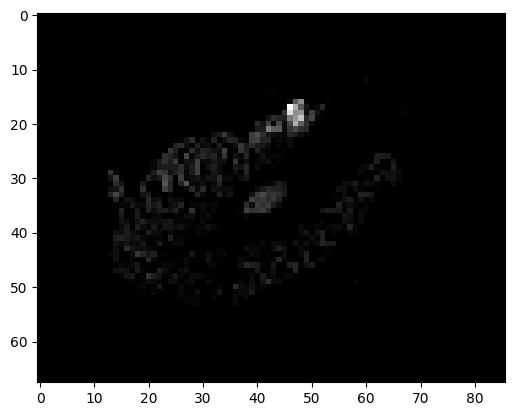

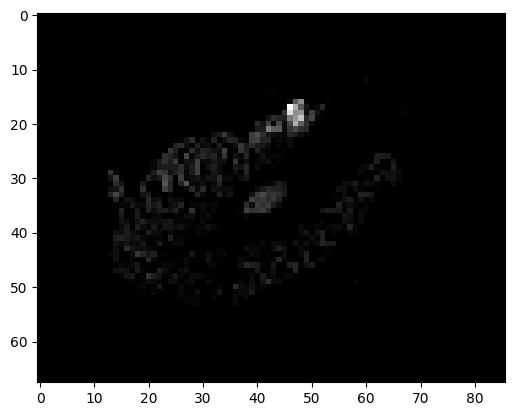

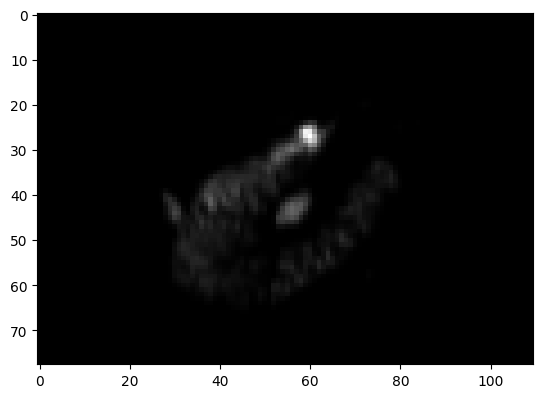

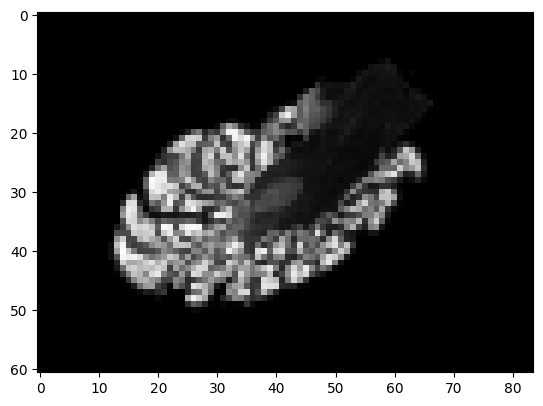

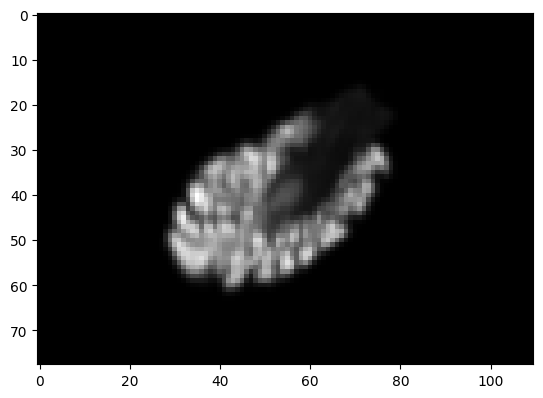

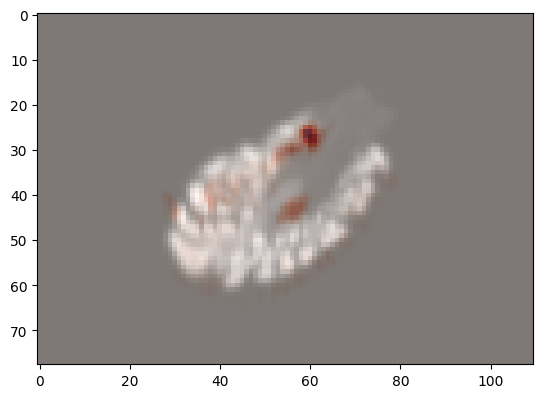

In [22]:

plt.imshow(np.rot90(_ds_label_cnt, k=0), cmap='gray')
plt.show()

plt.imshow(label_cnt_img.get_fdata(), cmap='gray')
plt.show()

plt.imshow(labeled_seq.get_fdata(), cmap='gray')
plt.show()

plt.imshow(src.get_fdata(), cmap='gray')
plt.show()

plt.imshow(seq, cmap='gray')
plt.show()

#overlay of labeled_seq and seq
plt.imshow(seq, cmap='gray')
plt.imshow(labeled_seq.get_fdata(), cmap='Reds', alpha=0.5,)
plt.show()

In [36]:
fname_header

'zefir_0251'

In [5]:
labeled_mask = glob(os.path.join(label_dir, f"{fname_header}_*_mask*.tif"))
labeled_mask_fname = labeled_mask[0]
labeled_mask = tiff.imread(labeled_mask_fname)
labeled_mask = labeled_mask.astype(bool).astype(np.uint8) #convert to binary mask
_ds = downsample_image(labeled_mask, 40, pad_value=-1*0) #this sets the pad value to be a negative value outside of the range of the data, which is important for the SDF computation later, since we want to make sure that the padding does not create artificial boundaries that will impact the SDF computation (since it will create a boundary between the data and the padding)

orig_cell_counts_fname = '/data/neuralabc/neuralabc_volunteers/macaque/testProject2/results_cell_counts/_Image_03_-_20x_cellCount_29_downsample_10p002um_pix.tif'
orig_cell_counts = tiff.imread(orig_cell_counts_fname)



Exception in worker
Traceback (most recent call last):
  File "/home/remoteuser/johmat/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/lib/python3.11/concurrent/futures/thread.py", line 81, in _worker
    work_item = work_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "src/gevent/queue.py", line 406, in gevent._gevent_cqueue.SimpleQueue.get
  File "src/gevent/queue.py", line 422, in gevent._gevent_cqueue.SimpleQueue.get
  File "src/gevent/queue.py", line 398, in gevent._gevent_cqueue.SimpleQueue._SimpleQueue__get_or_peek
  File "src/gevent/_waiter.py", line 154, in gevent._gevent_c_waiter.Waiter.get
  File "src/gevent/_greenlet_primitives.py", line 65, in gevent._gevent_c_greenlet_primitives.SwitchOutGreenletWithLoop.switch
  File "src/gevent/_gevent_c_greenlet_primitives.pxd", line 35, in gevent._gevent_c_greenlet_primitives._greenlet_switch
gevent.exceptions.LoopExit: This operation would block forever
	Hub: <Hub '' at 0x7f83f690bb50 epoll pending=0 r

In [15]:
print(f"labeled_mask shape, data type: {labeled_mask.shape}, {labeled_mask.dtype}")
print(f"orig_cell_counts shape, data type: {orig_cell_counts.shape}, {orig_cell_counts.dtype}")
print()
print(f"label_cnt_img shape: {label_cnt_img.shape}")
print(f"label_cnt_img max: {label_cnt_img.get_fdata().max()}")
print(f"label_cnt_img type: {type(label_cnt_img)}")
print(f"label_cnt_img data type: {label_cnt_img.get_fdata().dtype}")
print()
print(f"seq shape: {seq.shape}")
print(f"seq max: {seq.max()}")
print(f"seq type: {type(seq)}")
print(f"seq data type: {seq.dtype}")

print()
print(f"labeled_seq shape: {labeled_seq.shape}")
print(f"labeled_seq max: {labeled_seq.get_fdata().max()}")
print(f"labeled_seq min: {labeled_seq.get_fdata().min()}")
print(f"labeled_seq unique values: {np.unique(labeled_seq.get_fdata())}")
print(f"labeled_seq type: {type(labeled_seq)}")
print(f"labeled_seq data type: {labeled_seq.get_fdata().dtype}")



# plt.imshow(label_cnt_img.get_fdata(), cmap='gray', vmax=1)
# plt.show()

# plt.imshow(labeled_seq.get_fdata(), cmap='gray', vmax=1)
# plt.show()

labeled_mask shape, data type: (63158, 76025), uint8
orig_cell_counts shape, data type: (2178, 2622), float32

label_cnt_img shape: (77, 103)
label_cnt_img max: 36826.0
label_cnt_img type: <class 'nibabel.nifti1.Nifti1Image'>
label_cnt_img data type: float64

seq shape: (78, 110)
seq max: 1884.4905475617763
seq type: <class 'numpy.ndarray'>
seq data type: float64

labeled_seq shape: (78, 110)
labeled_seq max: 19397.741779849825
labeled_seq min: 0.0
labeled_seq unique values: [0.00000000e+00 4.50802904e-20 8.52141886e-19 ... 1.84379409e+04
 1.89901791e+04 1.93977418e+04]
labeled_seq type: <class 'nibabel.nifti1.Nifti1Image'>
labeled_seq data type: float64


In [159]:
rescale

580

In [ ]:
_ds1 = downsample_image(labeled_mask, 29, pad_value=-1*0) #this sets the pad value to be a negative value outside of the range of the data, which is important for the SDF computation later, since we want to make sure that the padding does not create artificial boundaries that will impact the SDF computation (since it will create a boundary between the data and the padding)
_ds2 = downsample_image(_ds1, 40, pad_value=-1*0) #this sets the pad value to be a negative value outside of the range of the data, which is important for the SDF computation later, since we want to make sure that the padding does not create artificial boundaries that will impact the SDF computation (since it will create a boundary between the data and the padding)






In [ ]:

input_res = 0.345
target_res = 10.0
rescale = target_res / input_res
rescale = int(round(rescale))

_ds3 = downsample_image(labeled_mask, rescale, pad_value=-1*0)

_ds3_simple = downsample_mask_to_counts(labeled_mask, rescale)

print(f"using version in this notebook: {_ds3_simple.shape} \nusing version in notebook (which has padding pre-ds): {_ds3.shape}")

using version in this notebook: (2177, 2621) 
 using version in notebook: (3050, 3671)


In [7]:
target_shape = orig_cell_counts.shape
current_shape = labeled_mask.shape
scale_factors = 1/(np.array(target_shape) / np.array(current_shape))

print(f"Target shape: {target_shape}")
print(f"Current shape: {current_shape}")
print(f"Scale factors: {scale_factors}")


Target shape: (2178, 2622)
Current shape: (63158, 76025)
Scale factors: [28.99816345 28.99504195]


In [47]:
input_res = 0.345
target_res = 10.0
rescale = target_res / input_res
rescale = int(round(rescale))


##THIS IS CORRECT BUT SLOW FOR TESTING (it turns cells into centroids before downsampling, which means that a singel cell doesnt get counted hundreds of times)
# centroid_seed_img = build_centroid_image(labeled_mask)
# ds_img = downsample_mask_to_counts(centroid_seed_img, rescale)
# ds_img_QP = downsample_mask_to_counts(centroid_seed_img, rescale, mode="qupath")

#THIS IS WRONG BUT FASTER FOR TESTING
ds_img = downsample_mask_to_counts(labeled_mask, rescale, mode="floor")
ds_img_QP = downsample_mask_to_counts(labeled_mask, rescale, mode="qupath")

print(f"factor={rescale}")
print(f"input shape = {labeled_mask.shape}")
print(f"floor downsampled shape = {ds_img.shape}")
print(f"qupath-like downsampled shape = {ds_img_QP.shape}")

factor=29
input shape = (63158, 76025)
floor downsampled shape = (2177, 2621)
qupath-like downsampled shape = (2178, 2622)


# copy and rename files

In [7]:
import csv
import os
import re
import shutil
from glob import glob

# Copy src + m1..m9 + final def0 registration files to a new directory.
# Renaming strategy:
# 1) remove leading zefir_XXXX marker,
# 2) append __TP# tag from CSV lookup so duplicate image names remain unique across projects.
# For duplicated stems, use occurrence-rank matching per stem (deterministic, avoids zefir-id trust).
root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'
dest_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies'
csv_lookup = '/data/neuralabc/johmat/phase_ml/source/all_TP_image_idxs_file_lookup.csv'
os.makedirs(dest_dir, exist_ok=True)

orig_fnames = sorted(glob(os.path.join(root_dir, 'zefir_????_*_pix.nii.gz')))

missing_slices = []
missing_csv_match = []
rank_mismatch_stems = []
copied = []
skipped_existing = []


def strip_zefir_marker(filename: str) -> str:
    out = re.sub(r'^zefir_\d{4}[_]*', '', filename)
    return out if out else filename


def parse_zefir_idx(name: str):
    m = re.match(r'^zefir_(\d{4})', name)
    return int(m.group(1)) if m else None


def normalize_image_stem(name_or_path: str) -> str:
    name = os.path.basename(name_or_path)
    name = re.sub(r'\.nii\.gz$', '', name)
    name = re.sub(r'\.tif$', '', name)
    name = strip_zefir_marker(name)
    return name.lstrip('_')


def split_ext_nii_gz(filename: str):
    if filename.endswith('.nii.gz'):
        return filename[:-7], '.nii.gz'
    base, ext = os.path.splitext(filename)
    return base, ext


def project_tag_from_path(file_path: str) -> str:
    m = re.search(r'/testProject(\d*)/', file_path)
    if not m:
        return 'TPX'
    digits = m.group(1)
    return f"TP{digits}" if digits else 'TP1'


# Build CSV lookup grouped by stem.
csv_by_stem = {}
with open(csv_lookup, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        stem = normalize_image_stem(row['file_name'])
        rec = {
            'idx': int(float(row['idx'])),
            'file_name': row['file_name'],
            'project_tag': project_tag_from_path(row['file_name']),
        }
        csv_by_stem.setdefault(stem, []).append(rec)

for stem in csv_by_stem:
    csv_by_stem[stem].sort(key=lambda r: r['idx'])


# Collect registration records first, then resolve TP tags per stem by rank.
reg_records = []
for orig_fname in orig_fnames:
    slice_name = os.path.basename(orig_fname)
    base_slice = slice_name.split('_downsample_10p002um_pix')[0]

    source_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix.nii.gz")
    mapping_img = os.path.join(root_dir, f"init_translation_slice_{base_slice.split('_')[1]}/{base_slice}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
    mapping_img3 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
    mapping_img4 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")
    mapping_img5 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter4_ants-map.nii.gz")
    mapping_img6 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter5_ants-map.nii.gz")
    mapping_img7 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter6_ants-map.nii.gz")
    mapping_img8 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter7_ants-map.nii.gz")
    mapping_img9 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter8_ants-map.nii.gz")
    mapping_img10 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-map.nii.gz")
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-def0.nii.gz")

    file_set = [
        source_img,            # src
        mapping_img,           # m1
        mapping_img3,          # m2
        mapping_img4,          # m3
        mapping_img5,          # m4
        mapping_img6,          # m5
        mapping_img7,          # m6
        mapping_img8,          # m7
        mapping_img9,          # m8
        mapping_img10,         # m9
        final_comparison_img,  # final def0
    ]

    if not all(os.path.exists(p) for p in file_set):
        missing_slices.append(slice_name)
        continue

    reg_records.append({
        'slice_name': slice_name,
        'source_img': source_img,
        'file_set': file_set,
        'stem': normalize_image_stem(source_img),
        'zefir_idx': parse_zefir_idx(slice_name),
    })

# Assign TP tag for every valid reg slice.
reg_by_stem = {}
for rec in reg_records:
    reg_by_stem.setdefault(rec['stem'], []).append(rec)

project_tag_by_source = {}
for stem, recs in reg_by_stem.items():
    recs_sorted = sorted(recs, key=lambda r: (r['zefir_idx'] is None, r['zefir_idx'], r['slice_name']))
    cands = csv_by_stem.get(stem, [])

    if len(cands) == 0:
        rank_mismatch_stems.append((stem, len(recs_sorted), 0))
        for rec in recs_sorted:
            project_tag_by_source[rec['source_img']] = 'TPX'
            missing_csv_match.append((rec['slice_name'], stem, rec['zefir_idx']))
        continue

    if len(cands) != len(recs_sorted):
        rank_mismatch_stems.append((stem, len(recs_sorted), len(cands)))

    # Rank-based mapping by occurrence order within this stem.
    n = min(len(cands), len(recs_sorted))
    for i in range(n):
        project_tag_by_source[recs_sorted[i]['source_img']] = cands[i]['project_tag']

    # Any extra reg entries get TPX.
    for i in range(n, len(recs_sorted)):
        rec = recs_sorted[i]
        project_tag_by_source[rec['source_img']] = 'TPX'
        missing_csv_match.append((rec['slice_name'], stem, rec['zefir_idx']))


for rec in reg_records:
    project_tag = project_tag_by_source.get(rec['source_img'], 'TPX')

    for src_path in rec['file_set']:
        src_name = os.path.basename(src_path)
        clean_name = strip_zefir_marker(src_name)
        base, ext = split_ext_nii_gz(clean_name)
        dst_name = f"{base}__{project_tag}{ext}"
        dst_path = os.path.join(dest_dir, dst_name)

        if os.path.exists(dst_path):
            skipped_existing.append((src_name, dst_name))
            continue

        shutil.copy2(src_path, dst_path)
        copied.append((src_path, dst_path, project_tag))

print(f"Slices found: {len(orig_fnames)}")
print(f"Slices with complete src+m1..m9+def0: {len(reg_records)}")
print(f"Files copied this run: {len(copied)}")
print(f"Existing destination files skipped: {len(skipped_existing)}")
print(f"Missing/incomplete slices skipped: {len(missing_slices)}")
print(f"CSV unmatched slices: {len(missing_csv_match)}")
print(f"Stem count mismatches: {len(rank_mismatch_stems)}")
print(f"Destination: {dest_dir}")

if missing_slices:
    print('First skipped slices:', missing_slices[:10])
if missing_csv_match:
    print('First CSV unmatched:', missing_csv_match[:5])
if rank_mismatch_stems:
    print('First stem count mismatches:', rank_mismatch_stems[:5])
if skipped_existing:
    print('First already-existing files skipped:', skipped_existing[:5])

Slices found: 398
Slices with complete src+m1..m9+def0: 398
Files copied this run: 4378
Existing destination files skipped: 0
Missing/incomplete slices skipped: 0
CSV unmatched slices: 0
Stem count mismatches: 0
Destination: /tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies


In [ ]:
skipped_existing[:20]

[('zefir_0127__Image_15_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz',
  'Image_15_-_20x_cellCount_29_downsample_10p002um_pix__dup1.nii.gz'),
 ('zefir_0127__Image_15_-_20x_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz',
  'Image_15_-_20x_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-map__dup1.nii.gz'),
 ('zefir_0127__Image_15_-_20x_cellCount_29_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz',
  'Image_15_-_20x_cellCount_29_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map__dup1.nii.gz'),
 ('zefir_0127__Image_15_-_20x_cellCount_29_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz',
  'Image_15_-_20x_cellCount_29_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map__dup1.nii.gz'),
 ('zefir_0127__Image_15_-_20x_cellCount_29_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter4_ants-map.nii.gz',
  'Image_15_-_20x_cellCount_29_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_gr

In [8]:
from pathlib import Path
import csv
import re

# Rename copied registration files by adding zefir_<idx> from CSV
# using (project tag, image number, optional tile 01/02) as the key.
target_dir = Path('/tmp/zefir_sliceReg_optimized_v2_rescale_40_renamed_copies')
lookup_csv = Path('/data/neuralabc/johmat/phase_ml/source/all_TP_image_idxs_file_lookup.csv')
dry_run = False  # set False to apply
keep_tp_tag = False  # if True, keep __TP# in output names

# CSV key parser: image number + optional tile (01/02)
image_key_pattern = re.compile(r'(?i)image_(\d+)_-_20x(?:_(01|02))?')

def project_tag_from_path(file_path: str) -> str:
    m = re.search(r'/testProject(\d*)/', file_path)
    if not m:
        return 'TPX'
    digits = m.group(1)
    return f"TP{digits}" if digits else 'TP1'

# Build lookup: (TP tag, image_num, tile) -> idx
idx_by_key = {}
with open(lookup_csv, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        csv_name = Path(str(row['file_name'])).name
        m = image_key_pattern.search(csv_name)
        if not m:
            continue
        image_num = int(m.group(1))
        tile = m.group(2) or ''
        tp = project_tag_from_path(str(row['file_name']))
        idx_by_key[(tp, image_num, tile)] = int(float(row['idx']))

# Parse copied files like:
# Image_03_-_20x_01_cellCount_29_downsample_10p002um_pix_coreg...__TP2.nii.gz
copied_pattern = re.compile(r'^(?P<stem>.+?)__(?P<tp>TP\d+|TPX)(?P<ext>\.nii\.gz)$', re.IGNORECASE)

renamed = 0
skipped = 0
unmatched = 0
already_prefixed = 0

for p in sorted(target_dir.glob('*.nii.gz')):
    name = p.name

    if name.startswith('zefir_'):
        already_prefixed += 1
        continue

    m = copied_pattern.match(name)
    if not m:
        skipped += 1
        continue

    stem = m.group('stem')
    tp = m.group('tp').upper()
    ext = m.group('ext')

    # TPX means previous step could not confidently map project.
    if tp == 'TPX':
        unmatched += 1
        print(f"UNMATCHED TPX: {name}")
        continue

    km = image_key_pattern.search(stem)
    if not km:
        unmatched += 1
        print(f"NO IMAGE KEY: {name}")
        continue

    image_num = int(km.group(1))
    tile = km.group(2) or ''
    idx = idx_by_key.get((tp, image_num, tile))

    if idx is None:
        unmatched += 1
        print(f"NO CSV MATCH: {name}")
        continue

    suffix = f"__{tp}" if keep_tp_tag else ''
    new_name = f"zefir_{idx:04d}__{stem}{suffix}{ext}"
    new_path = p.with_name(new_name)

    if p.name == new_name:
        continue

    if new_path.exists():
        print(f"SKIP (target exists): {p.name} -> {new_name}")
        skipped += 1
        continue

    print(f"RENAME: {p.name} -> {new_name}")
    if not dry_run:
        p.rename(new_path)
    renamed += 1

print(
    f"\nDone. Renamed: {renamed}, Unmatched: {unmatched}, "
    f"Skipped: {skipped}, Already prefixed: {already_prefixed}, Dry run: {dry_run}"
)

SKIP (target exists): Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix__TP1.nii.gz -> zefir_0000__Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
SKIP (target exists): Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix__TP3.nii.gz -> zefir_0397__Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
SKIP (target exists): Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-map__TP1.nii.gz -> zefir_0000__Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz
SKIP (target exists): Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-map__TP3.nii.gz -> zefir_0397__Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz
SKIP (target exists): Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map__TP1.nii.gz -> zefir_0000__Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz
SKIP (target exists): Image_01